# Завдання
### • дослідження даних та виявлення властивостей;
• оптимальний вибір моделі обробки – типу алгоритму експоненціального згладжування;
### • обробку та екстраполяцію вхідних даних;
### • оцінювання КРІ моделі, результатів обробки та екстраполяції;
### • візуалізацію / побудова графіків вхідних даних та результатів обробки/екстраполяції.
### дослідження даних та виявлення властивостей;
### • оптимальний вибір моделі обробки – типу алгоритму експоненціального згладжування;
### • обробку та екстраполяцію вхідних даних;
### • оцінювання КРІ моделі, результатів обробки та екстраполяції;
### • візуалізацію / побудова графіків вхідних даних та результатів обробки/екстраполяції.
### • оцінити КРІ результатів обробки, екстраполяції та якість моделі;
### • розробити рекомендації з ефективного використання експоненціального та регресійного згладжування;
### • на підставі сформованих рекомендацій розробити алгоритми вибору експоненціального або регресійного згладжування
 в залежності від властивостей вхідних даних.

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings("ignore")

# Load data

In [2]:
def load_and_clean(path='data/ev_cars.xlsx', column_names=None):
    if column_names is None:
        column_names = ['manufacturer', 'model', 'year', 'price', 'km_age', 'date_added']
    df = pd.read_excel(path, names=None)
    # ensure required cols exist (try to coerce)
    df = df.rename(columns={c: c.strip() for c in df.columns})
    # keep only relevant columns if present
    for c in column_names:
        if c not in df.columns:
            raise ValueError(f"Missing column {c} in input file")
    df = df[column_names].copy()

    # types
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

    # price cleanup
    df['price'] = df['price'].astype(str).str.replace('[$, ]', '', regex=True)
    df['price'] = df['price'].str.replace('\xa0', '', regex=False)
    df['price'] = df['price'].str.replace(' ', '', regex=False)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['km_age'] = pd.to_numeric(df['km_age'], errors='coerce')

    # drop rows with no date or no price
    df = df.dropna(subset=['date_added', 'price'])
    df = df.reset_index(drop=True)
    return df


# path to xlsx
path = 'data/ev_cars.xlsx'
df = load_and_clean(path)
df = df.sort_values('date_added')
df.head()

,manufacturer,model,year,price,km_age,date_added
9788,Maxus,Dana V1,2024,24900,1000,2025-08-24
9787,Renault,Zoe,2014,6300,114000,2025-08-30
9786,Kia,Niro,2020,19850,82000,2025-09-13
9785,Audi,e-tron,2022,47000,25000,2025-09-14
9784,Audi,e-tron,2019,29900,97000,2025-09-14


# EDA та features

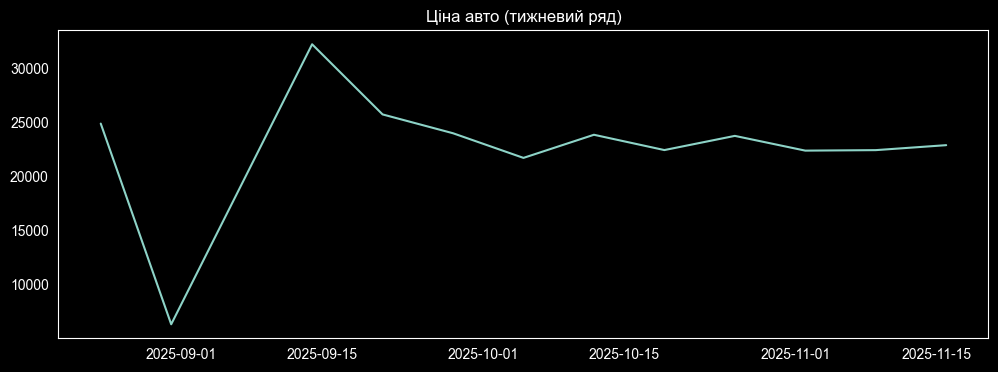

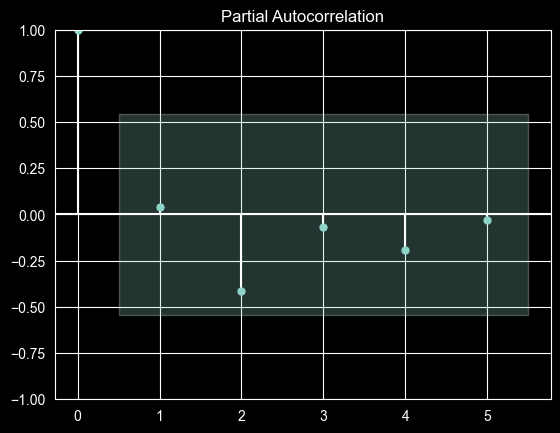

In [3]:
ts = df.set_index('date_added')['price'].resample('W').mean().interpolate()

plt.figure(figsize=(12,4))
plt.plot(ts)
plt.title("Ціна авто (тижневий ряд)")
plt.grid()
plt.show()

plot_acf(ts, lags=5)
plot_pacf(ts, lags=5)


# Exponential glide

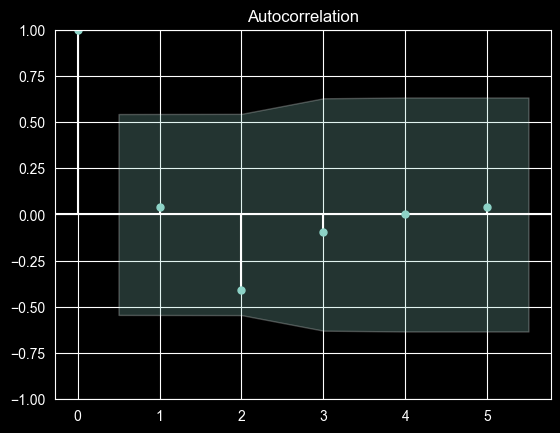

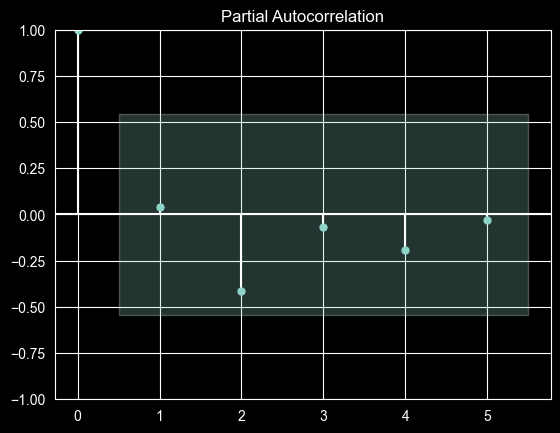

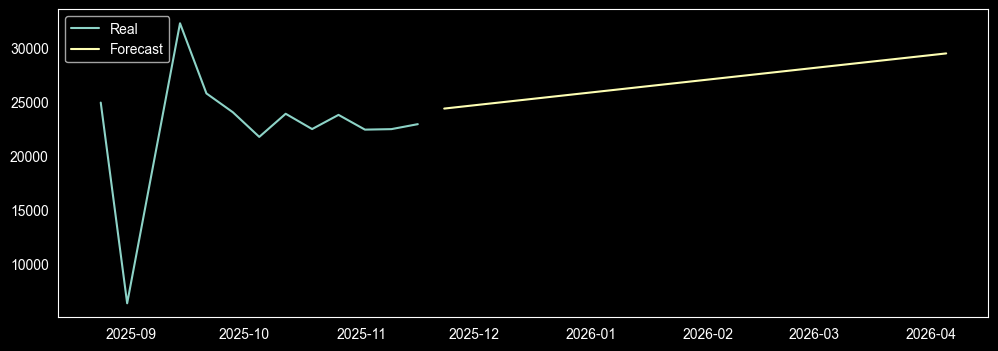

In [4]:
model_es = ExponentialSmoothing(ts, trend="add", seasonal=None)
fit_es = model_es.fit()
forecast_es = fit_es.forecast(20)

plt.figure(figsize=(12,4))
plt.plot(ts, label="Real")
plt.plot(forecast_es, label="Forecast")
plt.legend()
plt.grid()
plt.show()

mae_es = mean_absolute_error(ts[-50:], fit_es.fittedvalues[-50:])
mape_es = mean_absolute_percentage_error(ts[-50:], fit_es.fittedvalues[-50:])


# Regression model

In [5]:
df_reg = df[['year','km_age','price']]
X = df_reg[['year','km_age']]
y = df_reg['price']

tscv = TimeSeriesSplit(n_splits=5)
mae_list = []

for train, test in tscv.split(X):
    model = LinearRegression()
    model.fit(X.iloc[train], y.iloc[train])
    preds = model.predict(X.iloc[test])
    mae_list.append(mean_absolute_error(y.iloc[test], preds))

mae_reg = np.mean(mae_list)


# Synth generation

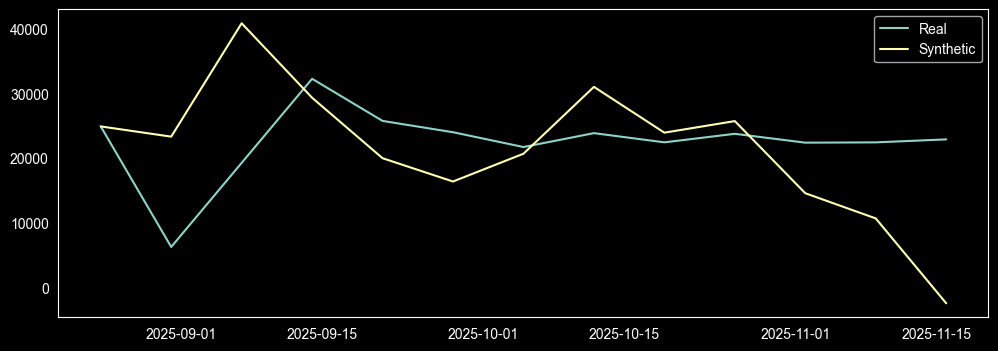

In [6]:
T = len(ts)
trend = (ts.iloc[-1] - ts.iloc[0]) / T
sigma = ts.diff().std()

synthetic = [ts.iloc[0]]
for t in range(1, T):
    synthetic.append(synthetic[-1] + trend + np.random.normal(0, sigma))

synthetic = pd.Series(synthetic, index=ts.index)

plt.figure(figsize=(12,4))
plt.plot(ts, label="Real")
plt.plot(synthetic, label="Synthetic")
plt.legend()
plt.grid()
plt.show()

# KPI's

In [7]:
print("=== KPI ===")
print("MAE ES:", mae_es)
print("MAPE ES:", mape_es)
print("MAE REG:", mae_reg)

=== KPI ===
MAE ES: 3370.766038950561
MAPE ES: 0.26669426652229195
MAE REG: 8090.629896322265
